In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 

Importing data

In [34]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\Notes\ML\Project\data\raw\spam.csv", encoding = "latin-1") # Load the dataset from the specified path using pandas' read_csv function. The encoding parameter is set to "latin-1" to handle any special characters in the dataset. 

Cleaning the data and dropping NaN values and label encoding one categorical feature.

In [35]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [36]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace = True)

In [37]:
df.rename(columns={"v1":"target", "v2": "text"},inplace = True) # Change the feature name from v1 to target and v2 to text

In [38]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target']) # Label encoded target column to 0 and 1.

In [39]:
df.isna().sum() # Check for null values in the dataset. There are no null values in the dataset.

target    0
text      0
dtype: int64

In [40]:
df.target.value_counts() # Check the distribution of ham and spam messages. The dataset is imbalanced with more ham messages than spam messages.

target
0    4825
1     747
Name: count, dtype: int64

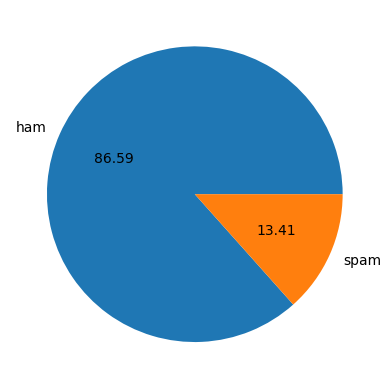

In [41]:
plt.pie(df.target.value_counts(), labels = ["ham","spam"], autopct = "%0.2f") # Visualize the distribution of ham and spam messages in the dataset using a pie chart.
plt.show() 

In [42]:
!pip install nltk
import nltk                # Natural Language Toolkit, a library for natural language processing tasks.
nltk.download("punkt_tab") # Download the punkt tokenizer models for tokenizing text into sentences and words.

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [43]:
# Counting the number of characters for each column
df["num_characters"] = df.text.apply(len)

In [44]:
# Counting the number of words in each column
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))

In [45]:
# Counting the number of sentences in each column
df["num_sentences"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [46]:
# Overview of the new columns added
df[["num_characters",	"num_words",	"num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
# Overview of the ham category
df[df["target"] == 0 ][["num_characters",	"num_words",	"num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [48]:
# Overview of the spam category
df[df["target"] == 1][["num_characters",	"num_words",	"num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


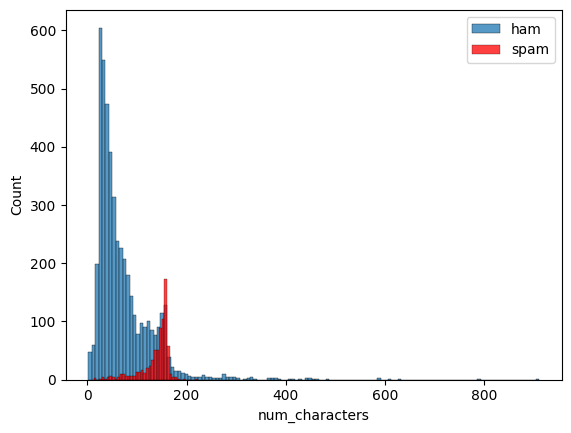

In [49]:
sns.histplot(df[df["target"] == 0]["num_characters"])
sns.histplot(df[df["target"] == 1]["num_characters"],color = 'red') # Visualize the distribution of the number of characters in ham and spam messages using histograms. Ham messages are shown in blue and spam messages are shown in red.
plt.legend(["ham","spam"])
plt.show()

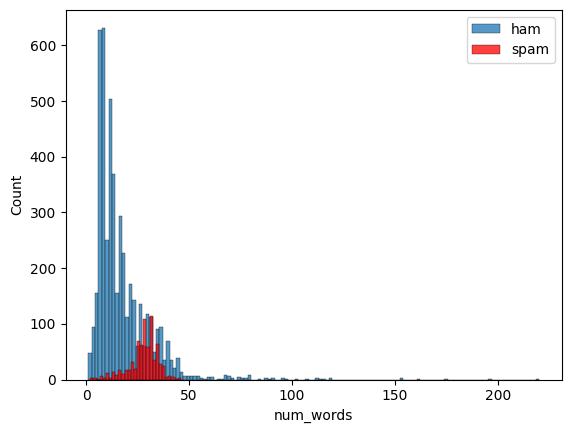

In [50]:
sns.histplot(df[df["target"] == 0]["num_words"])
sns.histplot(df[df["target"] == 1]["num_words"],color = 'red') # Visualize the distribution of the number of words in ham and spam messages using histograms. Ham messages are shown in blue and spam messages are shown in red.
plt.legend(["ham","spam"])
plt.show()

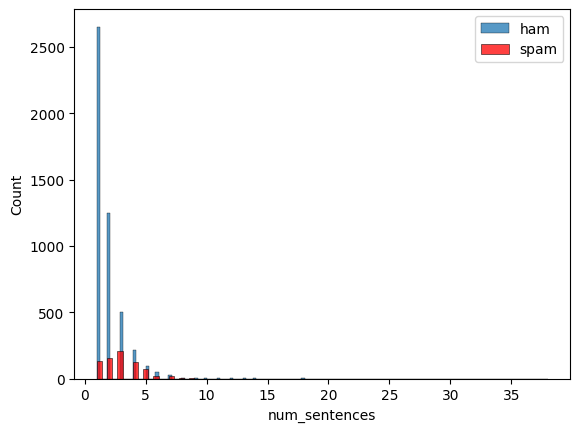

In [51]:
sns.histplot(df[df["target"] == 0]["num_sentences"])
sns.histplot(df[df["target"] == 1]["num_sentences"],color = 'red') # Visualize the distribution of the number of sentences in ham and spam messages using histograms. Ham messages are shown in blue and spam messages are shown in red.
plt.legend(["ham","spam"])
plt.show()

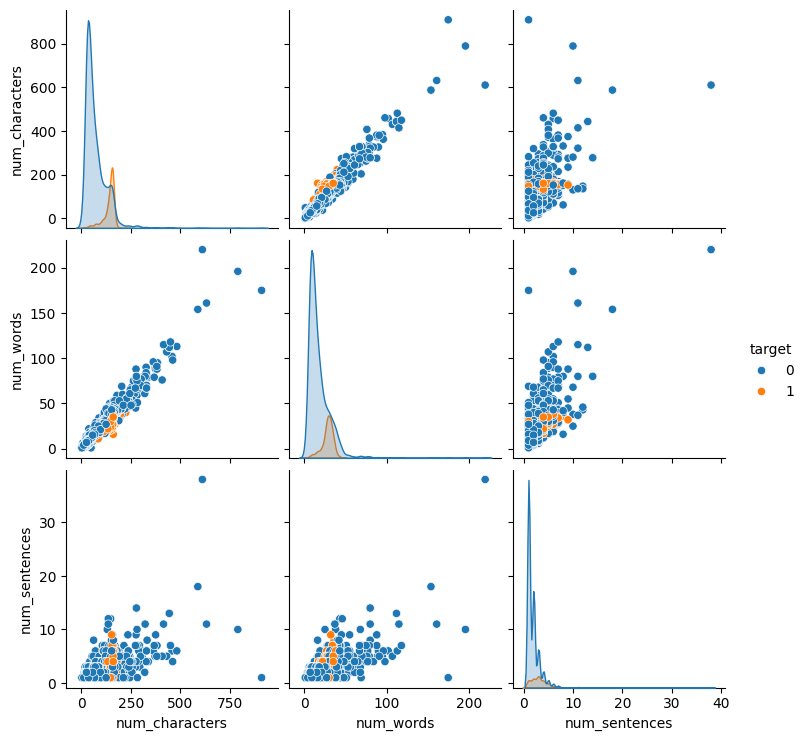

In [52]:
sns.pairplot(df, hue = "target") # Visualize the relationships between the number of characters, words, and sentences in ham and spam messages using a pair plot. The hue parameter is set to "target" to differentiate between ham and spam messages in the plot.
plt.show()

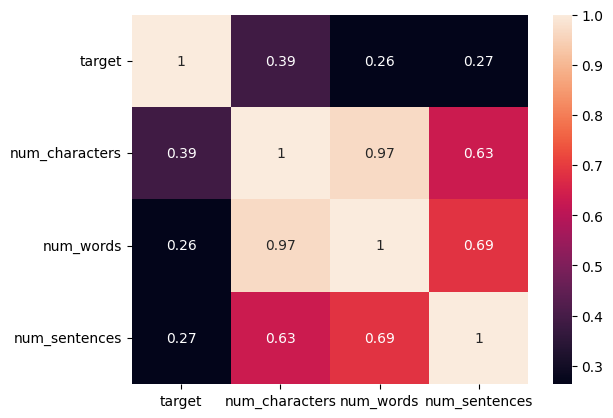

In [53]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(), annot = True) # Visualize the correlation between the target variable and the number of characters, words, and sentences in the messages using a heatmap. The annot parameter is set to True to display the correlation values in the heatmap.
plt.show()

Note :- There is strong multicollinearity between the columns hence we would use any one of them to detection the spam message.

In [54]:
# Export cleaned dataset for the text preprocessing stage

df.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
